<a href="https://colab.research.google.com/github/arpIIT09/stock-trend-predictor/blob/main/week4_soc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the feature dataset from Week 3
df = pd.read_csv(
    'AAPL_features.csv',
    index_col='Date',
    parse_dates=True
)

print('Shape:', df.shape)
print()
print(df.head())

Shape: (483, 9)

            Daily_Return         MA5  MA5_to_MA20  Price_to_MA20  Lag1_Return  \
Date                                                                            
2024-07-23      0.004688  223.333386     1.006762       1.005609    -0.001560   
2024-07-24     -0.028754  221.283142     0.995413       0.974631     0.004688   
2024-07-25     -0.004804  219.956635     0.988511       0.969032    -0.028754   
2024-07-26      0.002161  218.697540     0.982008       0.970292    -0.004804   
2024-07-29      0.001285  217.563367     0.975262       0.969893     0.002161   

            Lag2_Return  Volatility_5d  Volume_Change  Target  
Date                                                           
2024-07-23     0.000580       0.013523      -0.170979       0  
2024-07-24    -0.001560       0.014643       0.545974       0  
2024-07-25     0.004688       0.013195      -0.168126       1  
2024-07-26    -0.028754       0.013408      -0.190498       1  
2024-07-29    -0.004804       0

In [20]:
# Define our features and target — same list from Week 3
feature_cols = [
    'Daily_Return',
    'MA5',
    'MA5_to_MA20',
    'Price_to_MA20',
    'Lag1_Return',
    'Lag2_Return',
    'Volatility_5d',
    'Volume_Change'
]

X = df[feature_cols]   # features — the inputs
y = df['Target']       # target  — what we predict

print('X shape:', X.shape)
print('y shape:', y.shape)
print()
print('Target distribution:')
print(y.value_counts())
print(y.value_counts(normalize=True).round(3))


X shape: (483, 8)
y shape: (483,)

Target distribution:
Target
1    259
0    224
Name: count, dtype: int64
Target
1    0.536
0    0.464
Name: proportion, dtype: float64


In [21]:
# We split 80% for training, 20% for testing
# The split must respect time order — no shuffling

split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(f'Training rows : {len(X_train)}')
print(f'Test rows     : {len(X_test)}')
print()
print(f'Training period: {X_train.index[0].date()} to {X_train.index[-1].date()}')
print(f'Test period    : {X_test.index[0].date()}  to {X_test.index[-1].date()}')


Training rows : 386
Test rows     : 97

Training period: 2024-07-23 to 2026-02-04
Test period    : 2026-02-05  to 2026-06-25


In [6]:
from sklearn.linear_model import LogisticRegression

# Step 1: Create the model
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Step 2: Train it — 'fit' means 'learn from this data'
lr_model.fit(X_train, y_train)

print('Model trained!')



Model trained!


In [7]:
# Step 3: Make predictions on the test set
lr_predictions = lr_model.predict(X_test)

# Peek at the first 10 predictions vs the real answers
comparison = pd.DataFrame({
    'Actual':     y_test.values[:10],
    'Predicted':  lr_predictions[:10]
}, index=y_test.index[:10])

print('First 10 predictions vs actual:')
print(comparison)


First 10 predictions vs actual:
            Actual  Predicted
Date                         
2026-02-05       1          0
2026-02-06       0          0
2026-02-09       0          0
2026-02-10       1          0
2026-02-11       0          0
2026-02-12       0          0
2026-02-13       1          0
2026-02-17       1          0
2026-02-18       0          0
2026-02-19       1          0


In [8]:
# Step 4: Evaluate accuracy
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, lr_predictions)
print(f'Logistic Regression Accuracy: {lr_accuracy:.2%}')

# Also check training accuracy (useful for detecting overfitting later)
lr_train_accuracy = accuracy_score(y_train, lr_model.predict(X_train))
print(f'Training Accuracy           : {lr_train_accuracy:.2%}')


Logistic Regression Accuracy: 52.58%
Training Accuracy           : 55.44%


In [9]:
from sklearn.tree import DecisionTreeClassifier

# max_depth limits how many splits the tree can make, tree can ask at most 4 questions before making a prediction
# Without a limit, the tree will memorise the training data perfectly (overfitting)
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_predictions)
dt_train_accuracy = accuracy_score(y_train, dt_model.predict(X_train))

print(f'Decision Tree Test Accuracy : {dt_accuracy:.2%}')
print(f'Decision Tree Train Accuracy: {dt_train_accuracy:.2%}')


Decision Tree Test Accuracy : 51.55%
Decision Tree Train Accuracy: 62.95%


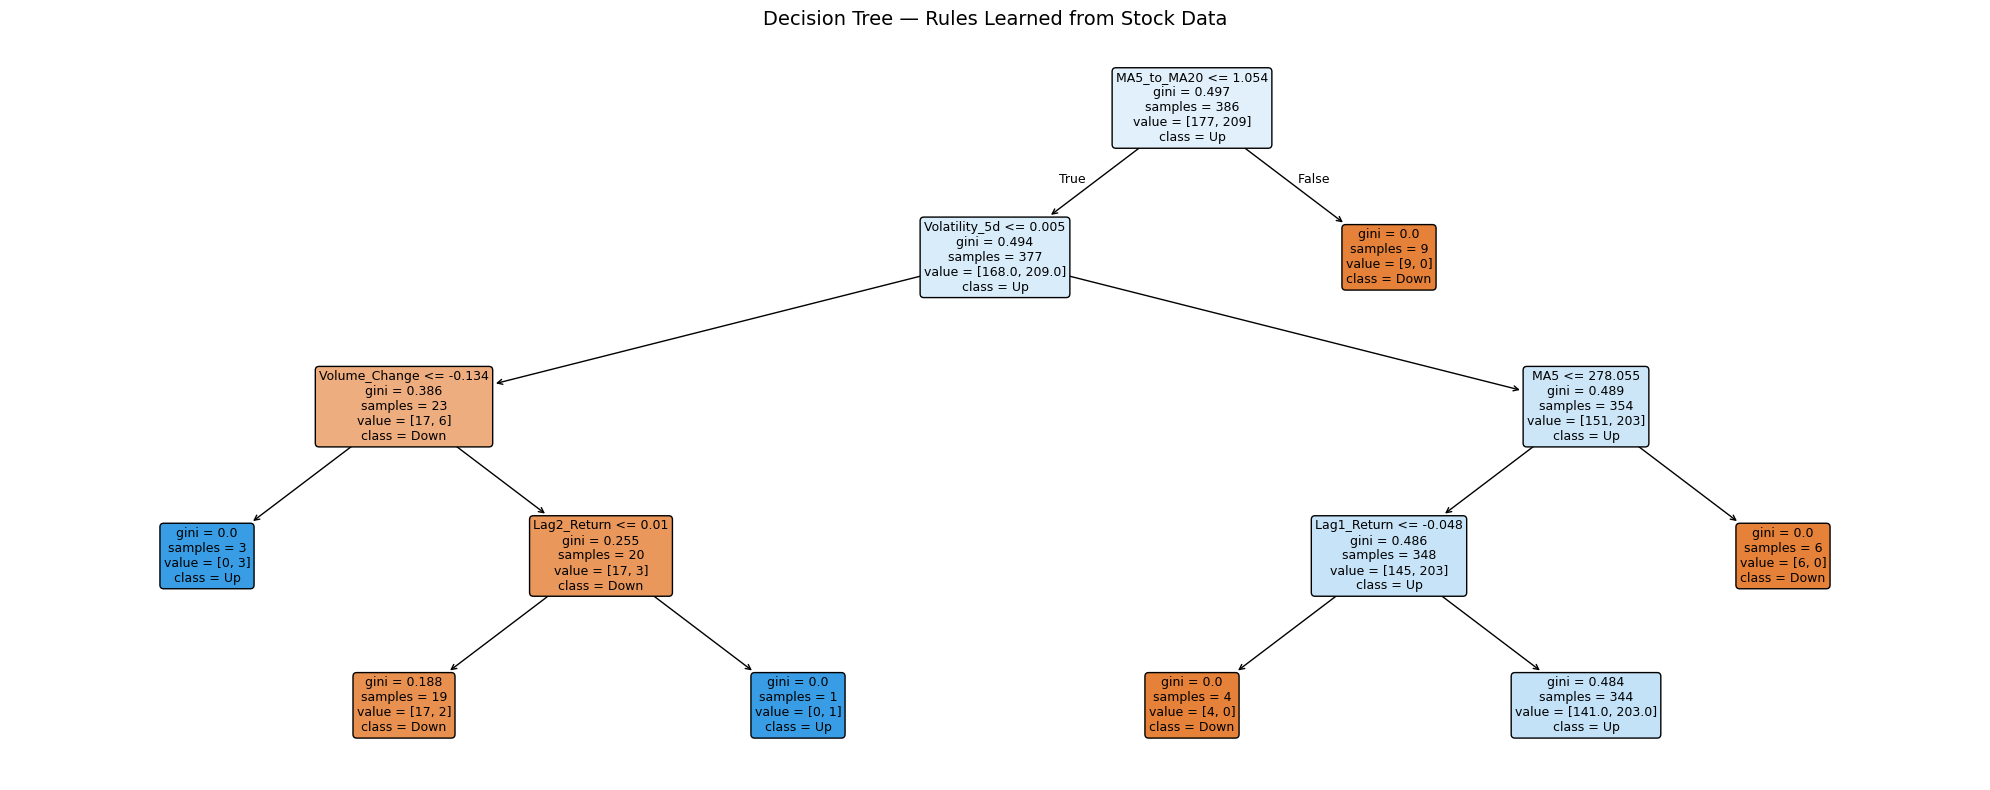

In [10]:
# Visualize the Decision Tree — see the rules it learned
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 8))
plot_tree(
    dt_model,
    feature_names=feature_cols,
    class_names=['Down', 'Up'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Decision Tree — Rules Learned from Stock Data', fontsize=14)
plt.tight_layout()
plt.show()


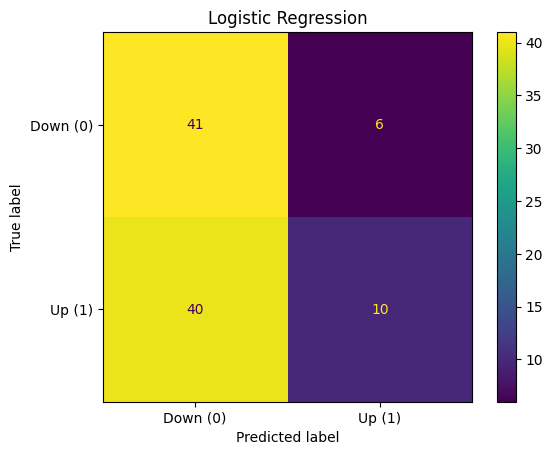

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, lr_predictions)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Down (0)', 'Up (1)']
).plot()

plt.title("Logistic Regression")
plt.show()


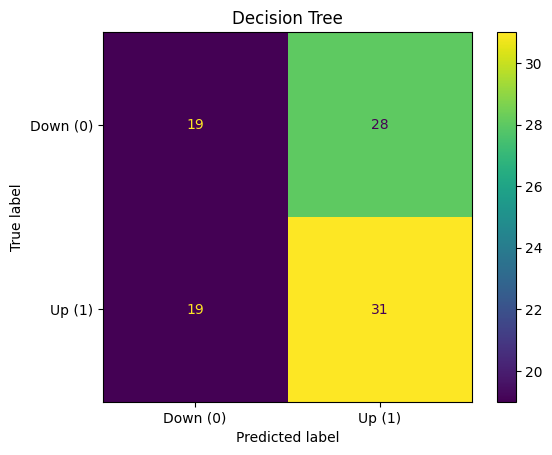

In [12]:
cm = confusion_matrix(y_test, dt_predictions)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Down (0)', 'Up (1)']
).plot()

plt.title("Decision Tree")
plt.show()

In [13]:
from sklearn.metrics import precision_score, recall_score

print('=== Logistic Regression ===')

print("Precision:", precision_score(y_test, lr_predictions))
print("Recall:", recall_score(y_test, lr_predictions))

print('=== Decision Tree ===')
print("Precision:", precision_score(y_test, dt_predictions))
print("Recall:", recall_score(y_test, dt_predictions))


=== Logistic Regression ===
Precision: 0.625
Recall: 0.2
=== Decision Tree ===
Precision: 0.5254237288135594
Recall: 0.62


                     Train Accuracy  Test Accuracy
Logistic Regression           55.44          52.58
Decision Tree                 62.95          51.55


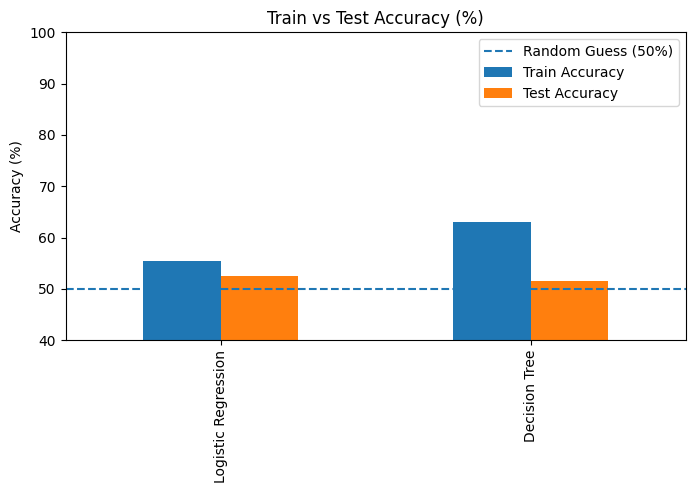

In [14]:
# Side-by-side comparison of both models
results = pd.DataFrame({
    'Train Accuracy': [lr_train_accuracy * 100,
                       dt_train_accuracy * 100],
    'Test Accuracy': [lr_accuracy * 100,
                      dt_accuracy * 100]
}, index=['Logistic Regression', 'Decision Tree'])

print(results.round(2))

results.plot(kind='bar', figsize=(8, 4))

plt.axhline(50, linestyle='--',
            label='Random Guess (50%)')

plt.ylabel("Accuracy (%)")
plt.title("Train vs Test Accuracy (%)")
plt.ylim(40, 100)

plt.legend()
plt.show()

In [15]:
# A tree with no depth limit will grow until every training row is perfectly classified
dt_overfit = DecisionTreeClassifier(max_depth=None, random_state=42)
dt_overfit.fit(X_train, y_train)

overfit_train_acc = accuracy_score(y_train, dt_overfit.predict(X_train))
overfit_test_acc  = accuracy_score(y_test,  dt_overfit.predict(X_test))

print(f'Unlimited Tree — Train Accuracy: {overfit_train_acc:.2%}')
print(f'Unlimited Tree — Test Accuracy : {overfit_test_acc:.2%}')
print()
print('Compare to our max_depth=4 tree:')
print(f'Depth-4 Tree  — Train Accuracy: {dt_train_accuracy:.2%}')
print(f'Depth-4 Tree  — Test Accuracy : {dt_accuracy:.2%}')


Unlimited Tree — Train Accuracy: 100.00%
Unlimited Tree — Test Accuracy : 48.45%

Compare to our max_depth=4 tree:
Depth-4 Tree  — Train Accuracy: 62.95%
Depth-4 Tree  — Test Accuracy : 51.55%


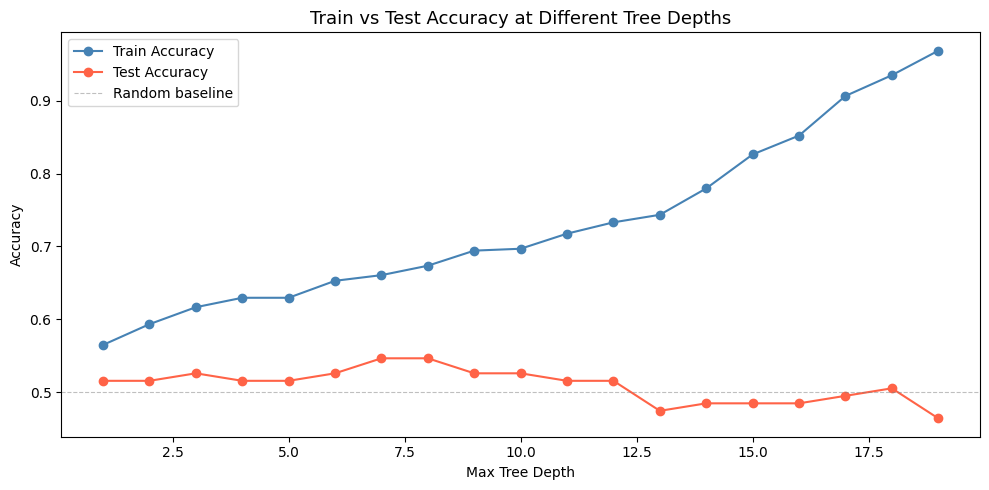

In [16]:
# How does test accuracy change as we increase tree depth?
depths = range(1, 20)
train_scores = []
test_scores  = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  model.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, label='Train Accuracy', marker='o', color='steelblue')
plt.plot(depths, test_scores,  label='Test Accuracy',  marker='o', color='tomato')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='Random baseline')
plt.xlabel('Max Tree Depth')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy at Different Tree Depths', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()


In [17]:
importances = pd.Series(dt_model.feature_importances_, index=feature_cols)

print(importances.sort_values(ascending=False).round(4))


MA5_to_MA20      0.2492
Volatility_5d    0.1946
MA5              0.1851
Volume_Change    0.1739
Lag1_Return      0.1270
Lag2_Return      0.0702
Price_to_MA20    0.0000
Daily_Return     0.0000
dtype: float64


In [18]:
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree (depth=4)', 'Decision Tree (unlimited — overfit)'],
    'Train Acc': [f'{lr_train_accuracy:.1%}', f'{dt_train_accuracy:.1%}', f'{overfit_train_acc:.1%}'],
    'Test Acc':  [f'{lr_accuracy:.1%}',       f'{dt_accuracy:.1%}',       f'{overfit_test_acc:.1%}'],
})
print(summary.to_string(index=False))


                              Model Train Acc Test Acc
                Logistic Regression     55.4%    52.6%
            Decision Tree (depth=4)     63.0%    51.5%
Decision Tree (unlimited — overfit)    100.0%    48.5%
